# First step
1. Importing all the required libraries, where I imported pandas and numpy for data manipulation, matplotlib for the visualization and sklearn for the model operation and train test split.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Task 1 is Simple Linear Regression

- We consider the single feature only as it is simple.
- We have to follow the clear 7 steps to build this ML pipeline so,

## Step 1 : Data retrieval and collection
- We were given the **housing.csv** as the dataset and I am using the same dataset in this pipeline.

In [3]:
import pandas as pd

df = pd.read_csv("housing.csv")

print("Shape:", df.shape)   # this gives the overall rows and column size as a tuple.
print("Columns:", df.columns) # this shows the name of all columns in dataset which is required later to drop or select for target and model.
df.head() # prints the top 5 rows of the dataset.

Shape: (20640, 10)
Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Step 2 : Data Cleaning
- In this step, I have check the missing values i.e. any rows with some missing values for particular column and  then I filled those missing values with the median of the total values of that particular column to ensure that there wont be large difference.


In [4]:
# Cheking missing values in the dataset.
print("Missing values in each column:")
print(df.isnull().sum())

# Handle missing values with median
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

# verifying the missing values
print("\nMissing values after cleaning:\n")
print(df.isnull().sum())

# checking the data types
print("\nData types of each column:\n")
print(df.dtypes)

Missing values in each column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing values after cleaning:

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Data types of each column:

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


C:\Users\ACER\AppData\Local\Temp\ipykernel_9648\2768472410.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


## Step 3 : Feature Design
- Selecting `housing_median_age` as the only input feature

-The feature **housing_median_age** represents the median age of houses in a district. It is a continuous numerical variable that may influence housing prices because:
 1. Older houses may be cheaper due to wear and depreciation.
 2. Newer houses may be more expensive due to modern construction.
 3. Age often reflects infrastructure quality and neighborhood development.

As this is a simple linear regression model with one predictor, this feature was selected as a reasonable variable that could have a linear relationship with house price.

In [5]:
# Select housing_median_age as the only input feature
X = df[["housing_median_age"]]

# Select target variable 
y = df["median_house_value"]

# Verify shapes
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

# Preview data
print("\nFeature sample:")
print(X.head())

print("\nLabel sample:")
print(y.head())

Feature shape: (20640, 1)
Label shape: (20640,)

Feature sample:
   housing_median_age
0                41.0
1                21.0
2                52.0
3                52.0
4                52.0

Label sample:
0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64


## Step 4 : Algorithm selection
- I selected the linear regression model from sklearn as this is the simple regression problem.

In [6]:

# Select Linear Regression algorithm
model_simple = LinearRegression()

print("Selected algorithm:", type(model_simple).__name__)

Selected algorithm: LinearRegression


## Step 5 : Loss function selection
- I used **MSE** as said in assingment.
- It is used because it measures how well the model's predictions match with the actual values.
- It calculates **average of the squared difference between predicted and actual house prices.**

### Smaller MSE means better model performance.


In [7]:

# Define loss function
loss_function = mean_squared_error

print("Selected Loss Function:", loss_function.__name__)

Selected Loss Function: mean_squared_error


## Step 6 : Model Training
- Split the data into training and testing sets
- Train the linear regression model
- Clearly state the learning process

I splitted the dataset as : **20 percent test and 80 percent train**. The training set helps the model to learn the relationship between housing median and house value whereas test set is used to evaluate the model performance on unseen data.

### During training, the linear regression algorithm learns the best fitting line by minimizing the Mean Squared Error between predicted and actual values.

In [8]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the linear regression model
model_simple.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Step 7 : Model Evaluation
 
The task to be done in this steps are :
- Evaluate the model on test data
- Report:
  - Mean Squared Error (MSE)
  - (Optional) R² Score
- Provide a short interpretation of the results

And my implementation gave the result as :

1. **Mean Squared Error (MSE): 12,939,617,265.100323**
This value represents the average squared difference between the predicted house prices and the actual house prices.
Since the unit of median_house_value is in dollars, the MSE is very large, indicating that the model’s predictions deviate significantly from the true values.

2. **R² Score: 0.0125 (~1.25%)**
The R² score indicates how much of the variance in house prices is explained by the model. Here, only about 1% of the variation in house prices is explained by housing_median_age. This is extremely low, meaning housing median age alone is a very poor predictor of house prices.

In [9]:
# Make predictions on test data
y_pred = model_simple.predict(X_test)

# Calculate evaluation metrics
mse_simple = loss_function(y_test, y_pred)
r2_simple = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse_simple)
print("R² Score:", r2_simple)

Mean Squared Error (MSE): 12939617265.100323
R² Score: 0.012551235533311389


## Visualizing the regression line
- The scatter plot shows the actual house prices in the test set (blue points) against housing_median_age.
- The red line is the regression line predicted by the model.
- We can see that the points are widely scattered around the line, which visually confirms that housing_median_age alone is not a strong predictor.

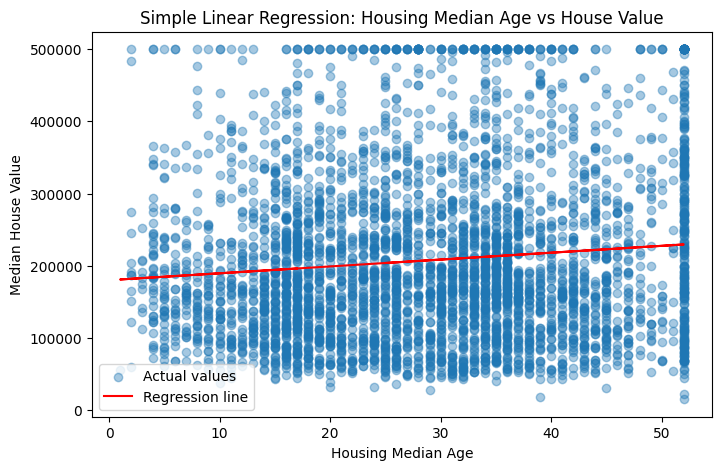

In [10]:

plt.figure(figsize=(8,5))

# Scatter plot of actual test points
plt.scatter(X_test, y_test, alpha=0.4, label="Actual values")

# Regression line
plt.plot(X_test, y_pred, color="red", label="Regression line")

plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression: Housing Median Age vs House Value")
plt.legend()
plt.show()

## Predicted VS Actual plot
- This plot compares predicted house values (y-axis) with actual house values (x-axis).
- The red dashed line represents perfect prediction (y = x).
- Points scattered far from the line indicate poor prediction accuracy.
- The plot confirms our earlier metrics (low R² and high MSE), showing that a single feature is insufficient to predict housing prices accurately.

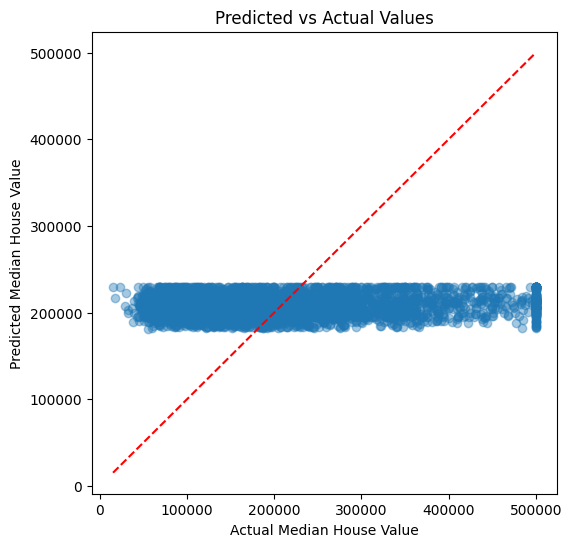

In [11]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Predicted vs Actual Values")
plt.show()

## Model Interpretation

1. **Coefficient (slope = β₁)**

- The slope represents the change in median house value for a one-year increase in housing median age.
- If slope is positive, prices increase with age; if negative, prices decrease with age.
- In our model, the slope is very small, indicating that housing_median_age has almost no effect on house prices.

2. **Intercept (β₀)**

- The intercept is the predicted median house value when housing_median_age = 0. While age = 0 is unrealistic, the intercept is necessary for the regression line equation.

3. **Regression Equation:**

Predicted Price = Intercept + (Coefficient × Housing Median Age)

In [12]:
# Coefficient (slope)
slope = model_simple.coef_[0]

# Intercept
intercept = model_simple.intercept_

print("Coefficient (slope):", slope)
print("Intercept:", intercept)

Coefficient (slope): 951.4618671495982
Intercept: 179975.00158647486


# Task 2 : Multiple Linear Regression

- Here we are using the same dataset as simple regression but it contains the **all features as input expect the target which is median_house_value**

- The same 7 steps as before are required to build the ML pipeline but the features has to be changed.

## Step 1 : Data retrieval and collection.

Here label/target = median_house_value 
and features are = California Housing dataset

In [13]:
# Dataset already loaded as df
print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (20640, 10)
Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Step 2 : Data cleaning
- This is also the same as that of the task 1.
- As the missing value is already handled in task 1 and I am using the same cleaned dataset so there are no any missing values in there.
- But I have done the code for how it can be handled.

In [14]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing total_bedrooms as before
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

# Verify data types
print("\nData types:\n", df.dtypes)

Missing values:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Data types:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


C:\Users\ACER\AppData\Local\Temp\ipykernel_9648\1046526771.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


## Step 3 : Feature Design

- We use **all numerical features except the label** as input variables.
- Feature scaling (standardization) ensures that all variables are on a similar scale, which helps the model converge efficiently.
- Using multiple features allows the model to consider more factors affecting house prices, improving prediction performance which was a cons in simple linear regression.

In [15]:
# Drop label and categorical column
X_multi = df.drop(columns=["median_house_value", "ocean_proximity"], errors="ignore")
y_multi = df["median_house_value"]

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)

print("Feature matrix shape:", X_scaled.shape)
print("Label vector shape:", y_multi.shape)

Feature matrix shape: (20640, 8)
Label vector shape: (20640,)


## Step 4 : Algorithm Selection

- This is also similar to the simple linear regression where we use the **Linear Regression because the target variable is continuous**
- Using multiple features, the model learns a linear combination of predictors to explain variations in housing prices.

In [16]:
model_multi = LinearRegression()
print("Selected Algorithm:", type(model_multi).__name__)

Selected Algorithm: LinearRegression


## Step 5 : Loss function selection

- As we have to measure the models performance so selecting the loss function is the most important part and here we use **MSE** to measure the prediction error.
- It calculates the average squared difference between predicted and actual house values.
- **smaller MSE = better prediction accuracy.**

In [17]:
# Define loss function
loss_function = mean_squared_error
print("Selected Loss Function:", loss_function.__name__)

Selected Loss Function: mean_squared_error


## Step 6 : Model Training 

- The training set is used to learn the relationship between multiple input features and house prices.
- The model finds coefficients for each feature that minimize MSE on the training data.

Here, the model learns from many features not only single. Thus called mutliple linear regression.

In [18]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi, test_size=0.2, random_state=42
)

model_multi.fit(X_train_m, y_train_m)
print("Model training completed.")

Model training completed.


## Step 7 : Model Evaluation

- In this code, MSE and R² score evaluate model performance on unseen test data.
- A lower MSE and higher R² (closer to 1) indicate better predictive ability.
Using multiple features usually improves R² compared to single-feature regression because the model considers more factors.

In [19]:
from sklearn.metrics import r2_score

# Make predictions
y_pred_m = model_multi.predict(X_test_m)

# Evaluate
mse_multi = loss_function(y_test_m, y_pred_m)
r2_multi = r2_score(y_test_m, y_pred_m)

print("Mean Squared Error (MSE):", mse_multi)
print("R² Score:", r2_multi)

Mean Squared Error (MSE): 5059928371.1653595
R² Score: 0.6138664756435174


## Model interpretation

1. **Intercept**: predicted house value when all features are zero (baseline).

2. **Coefficient for each feature**: the expected change in house value per one unit increase in that feature, holding others constant.

Compared to the single feature model, this model captures the effect of all relevant features, so predictions are more accurate and the model better explains the variance in prices.


In [22]:
# Coefficients
coefficients = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": model_multi.coef_
})

# Intercept
intercept = model_multi.intercept_

print("Intercept:", intercept)
print(coefficients)

Intercept: 206640.6370318638
              Feature   Coefficient
0           longitude -85413.280057
1            latitude -90669.136247
2  housing_median_age  14885.958358
3         total_rooms -17862.582941
4      total_bedrooms  48757.372097
5          population -43589.917358
6          households  17717.714859
7       median_income  77013.875352


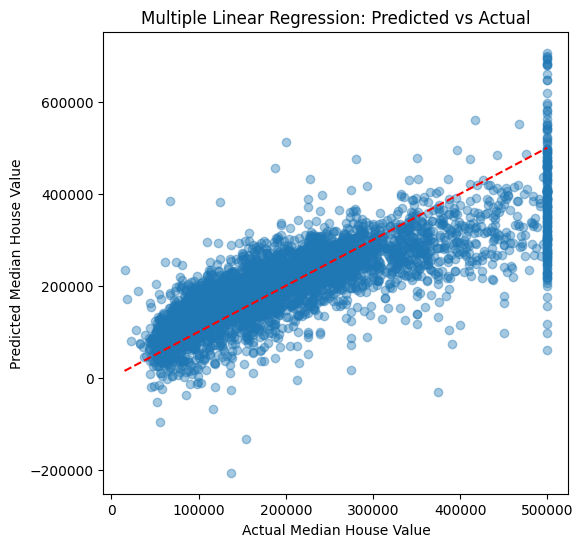

In [23]:
# Plotting actual vs predicted values

plt.figure(figsize=(6,6))
plt.scatter(y_test_m, y_pred_m, alpha=0.4)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], color="red", linestyle="--")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Multiple Linear Regression: Predicted vs Actual")
plt.show()

## Model Comparison: Simple vs Multiple Linear Regression

### Task 1: Simple Linear Regression
- **Feature used:** housing_median_age  
- **Coefficient (slope):** 951.46 → house value increases by ~$951 for each year increase in age  
- **Intercept:** 179,975 → predicted value when age is 0  
- **MSE:** 12,939,617,265 → predictions are far from actual values  
- **R²:** 0.0125 (~1%) → feature explains almost nothing  

**Observation:** This model doesn’t predict well because house prices depend on many things, not just age.

---

### Task 2: Multiple Linear Regression
- **Features used:** longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income  
- **Intercept:** 206,641  
- **Coefficients:**  
  - longitude: -85,413  
  - latitude: -90,669  
  - housing_median_age: 14,886  
  - total_rooms: -17,863  
  - total_bedrooms: 48,757  
  - population: -43,590  
  - households: 17,718  
  - median_income: 77,014  
- **MSE:** 5,059,928,371 → much smaller, better predictions  
- **R²:** 0.614 (~61%) → explains most of the variation  

**Observation:** Using multiple features improves accuracy because it includes many factors affecting house prices.

---

### Comparison
- Multiple regression is **more accurate** (lower MSE, higher R²)  
- Simple regression is **easier to interpret** (1 coefficient)  
- Multiple regression captures more details but is slightly harder to explain


- The multiple linear regression model performs better. It has a much lower MSE (5,059,928,371 vs 12,939,617,265) and a higher R² (0.614 vs 0.0125), meaning it predicts house prices more accurately.  

- Using multiple features helps because house prices depend on many factors like income, population, rooms, and location. Considering more features allows the model to capture these effects and make better predictions. Single-feature regression ignores all other important factors, so its performance is poor.  

- The simple linear regression model is easier to interpret since it has only one coefficient and one intercept. Multiple regression is more complex with several coefficients, but it gives more accurate results.

**Conclusion:** Using multiple features gives better predictions, while single-feature models are simpler but weak.